<a href="https://colab.research.google.com/github/ManiSZNN/ManiSZNN/blob/main/Jayden_Thomas_DSD_'26_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###The Efficacy of Prestige: Do Name Value Schools Really Yield Better Outcomes?


---



---
This study attempts to check whether there exists merit for the growing perception that going to, or not going to, this nation's elite insitutions will dramatically alter what your career trajectory will look like. It will answer 4 core questions:


---


* Does the selctiveness of a college
directly link to better outcomes?

* Does the required profile for entry directly link to better outcomes?

* Does higher cost directly link to better outcomes?

* Does the ranking of the college lead to better outcomes?

* Is the academic prowess of the college the determining factor for job placement?


### I: The Data


---
The data I wished to look at were all specific to ENGIEERING exclusively. I wanted to compare, by U.S News/Report ranking, the top 120 engineering schools by student stats, selectiveness, cost, and outcomes.

The parameters I wished to study were rather specific and the datasets publically available didn't quite fulfil each need. Because of that, I created a template dataframe with the top 10 schools and then tasked Gemini to refer to the U.S. News and World rankings for the schools and then fill out the data based on the DOE College Scorecard via the data.gov API key. While I was able to generate a valid CSV, the data was broadly inaccurate and required manual verification and re-entry.

The AI retained some of the columns I was using for my personal research, I have dropped them from the df to make it easier to analyze.

####!Disclaimer! The data for cost is from the DOE and college websites, it measures for the average student that qualifies for financial aid. A bibliography will be at the bottom of the notebook.



In [3]:
import pandas as pd
from google.colab import drive
drive.mount("/content/drive")
ai_college_list = pd.read_csv("/content/drive/My Drive/modified_top_120_engineering_programs (2).csv")
ai_college_list = ai_college_list.drop(columns = ['Choice', 'Black %', "Notes","Supplements? (.5 means optional)",'Early Action?','Restricted Early Action?','Early Decision?'])
ai_college_list_analysis = ai_college_list.drop(columns = ["Engineering Rank"])
ai_college_list = ai_college_list.sort_values(by = "Engineering Rank")
ai_college_list

Mounted at /content/drive


,Name,Engineering Rank,AR,Avg. GPA,Avg. ACT,Average Annual Cost,Graduation Rate,Median Earnings
0,MIT,1,4.0,4.00,35.5,20232,0.95,162000
1,Stanford,2,4.0,3.99,35.0,14443,0.97,137000
2,UC Berkeley,3,11.0,3.93,34.0,19329,0.93,96000
3,Georgia Tech,3,12.0,3.91,33.5,38000,0.93,119000
4,Caltech,5,3.0,3.99,36.0,16000,0.94,153000
...,...,...,...,...,...,...,...,...
118,Wichita State,104,92.0,3.60,24.5,14500,0.51,74000
115,U of Toledo,104,94.0,3.55,24.5,17500,0.48,73000
122,"Embry-Riddle (Prescott, AZ)",116,71.0,3.82,27.0,40966,0.71,94000
121,Embry-Riddle (Daytona Beach),116,66.0,3.75,27.0,39886,0.66,94000


#II: EDA


---
To understand our data more clealry, I ran a df.describe function to easily display some key characteriscts concering the data we are going to look at.

The incoming freshman stat means/medians are practically identical except for acceptance rate, as the median is 110% of the mean. This indicates that the highly selective colleges are dragging down the total average and the real "normal" AR is slightly above what our math would indicate.

The same process occurs with the average cost and graduation rate while the reverse occurs median earnings. The cost and GR means are dragged down by affordable schools and schools used as transfer launchpads. The median earnings are dragged up by some schools' grads earning significantly more than the average or even the 75th percentile.

This data can give us benchmarks for "good" "average" and "bad" schools going forward.

In [4]:
stats_analysis = ai_college_list_analysis.describe()
stats_analysis

,AR,Avg. GPA,Avg. ACT,Average Annual Cost,Graduation Rate,Median Earnings
count,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000
mean,50.419106,3.796911,30.182927,31470.650407,0.798699,89658.024390
std,30.158388,0.119638,3.276386,11880.790283,0.123647,17515.100148
min,3.000000,3.500000,24.500000,3200.000000,0.480000,68000.000000
25%,17.500000,3.700000,27.500000,21500.000000,0.710000,78000.000000
50%,55.000000,3.800000,30.500000,33110.000000,0.820000,82000.000000
75%,79.500000,3.900000,33.250000,40000.000000,0.895000,96000.000000
max,96.000000,4.000000,36.000000,57878.000000,0.980000,162000.000000


In [5]:
ai_college_list["Median Earnings"].median()

82000.0

#Visualizations For Thought


---
While not explicitly the data analysis, the pure data set can be used for comparison. For each plot, the r value (correlation between variables where 1 or -1 is direct corrleation and 0 is no correlation) is displayed above

Plot #1 compares the cost of schools to their acceptance rate. It also colors the schools by income groupings intervaled by $20,000. It highlights the paradoxical nature of top colleges giving near total financial aid to those who are eligible. Though there is practically no correlation, notice the clear drop in tuition at and below the 10% mark and the clear darkening of the circles.






np.float64(0.28367849735552547)

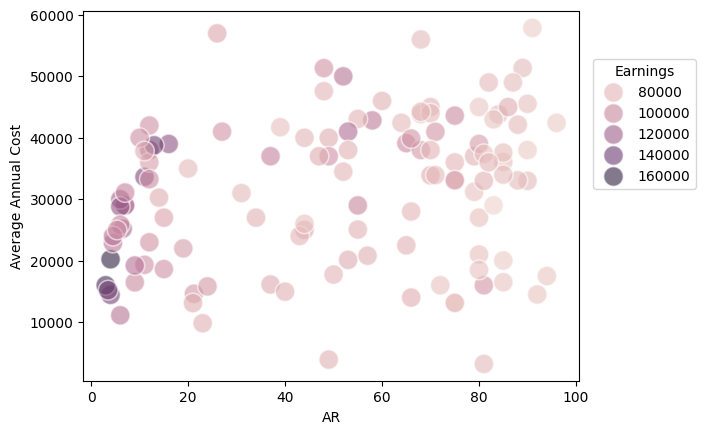

In [6]:

#Plot 1
import seaborn as sns
plt1 = sns.scatterplot(ai_college_list, x="AR", y= 'Average Annual Cost' , s = 200, alpha = .6, hue = "Median Earnings")
plt1.legend(title = "Earnings", loc = "lower right",
  bbox_to_anchor = (1.25,0.5))
ai_college_list["AR"].corr(ai_college_list["Average Annual Cost"])


Plot #2 compares the Engineering Rank of the Schools to the median earnings of graduates after school. The trend is mostly what you'd expect, with top colleges yielding seriosuly high earnings and a general downwards trend as the rankings progress. You will also notice some mid-ranked schools producing earners comprable to the "elite". I will elaborate on this later.


np.float64(-0.5723929475493874)

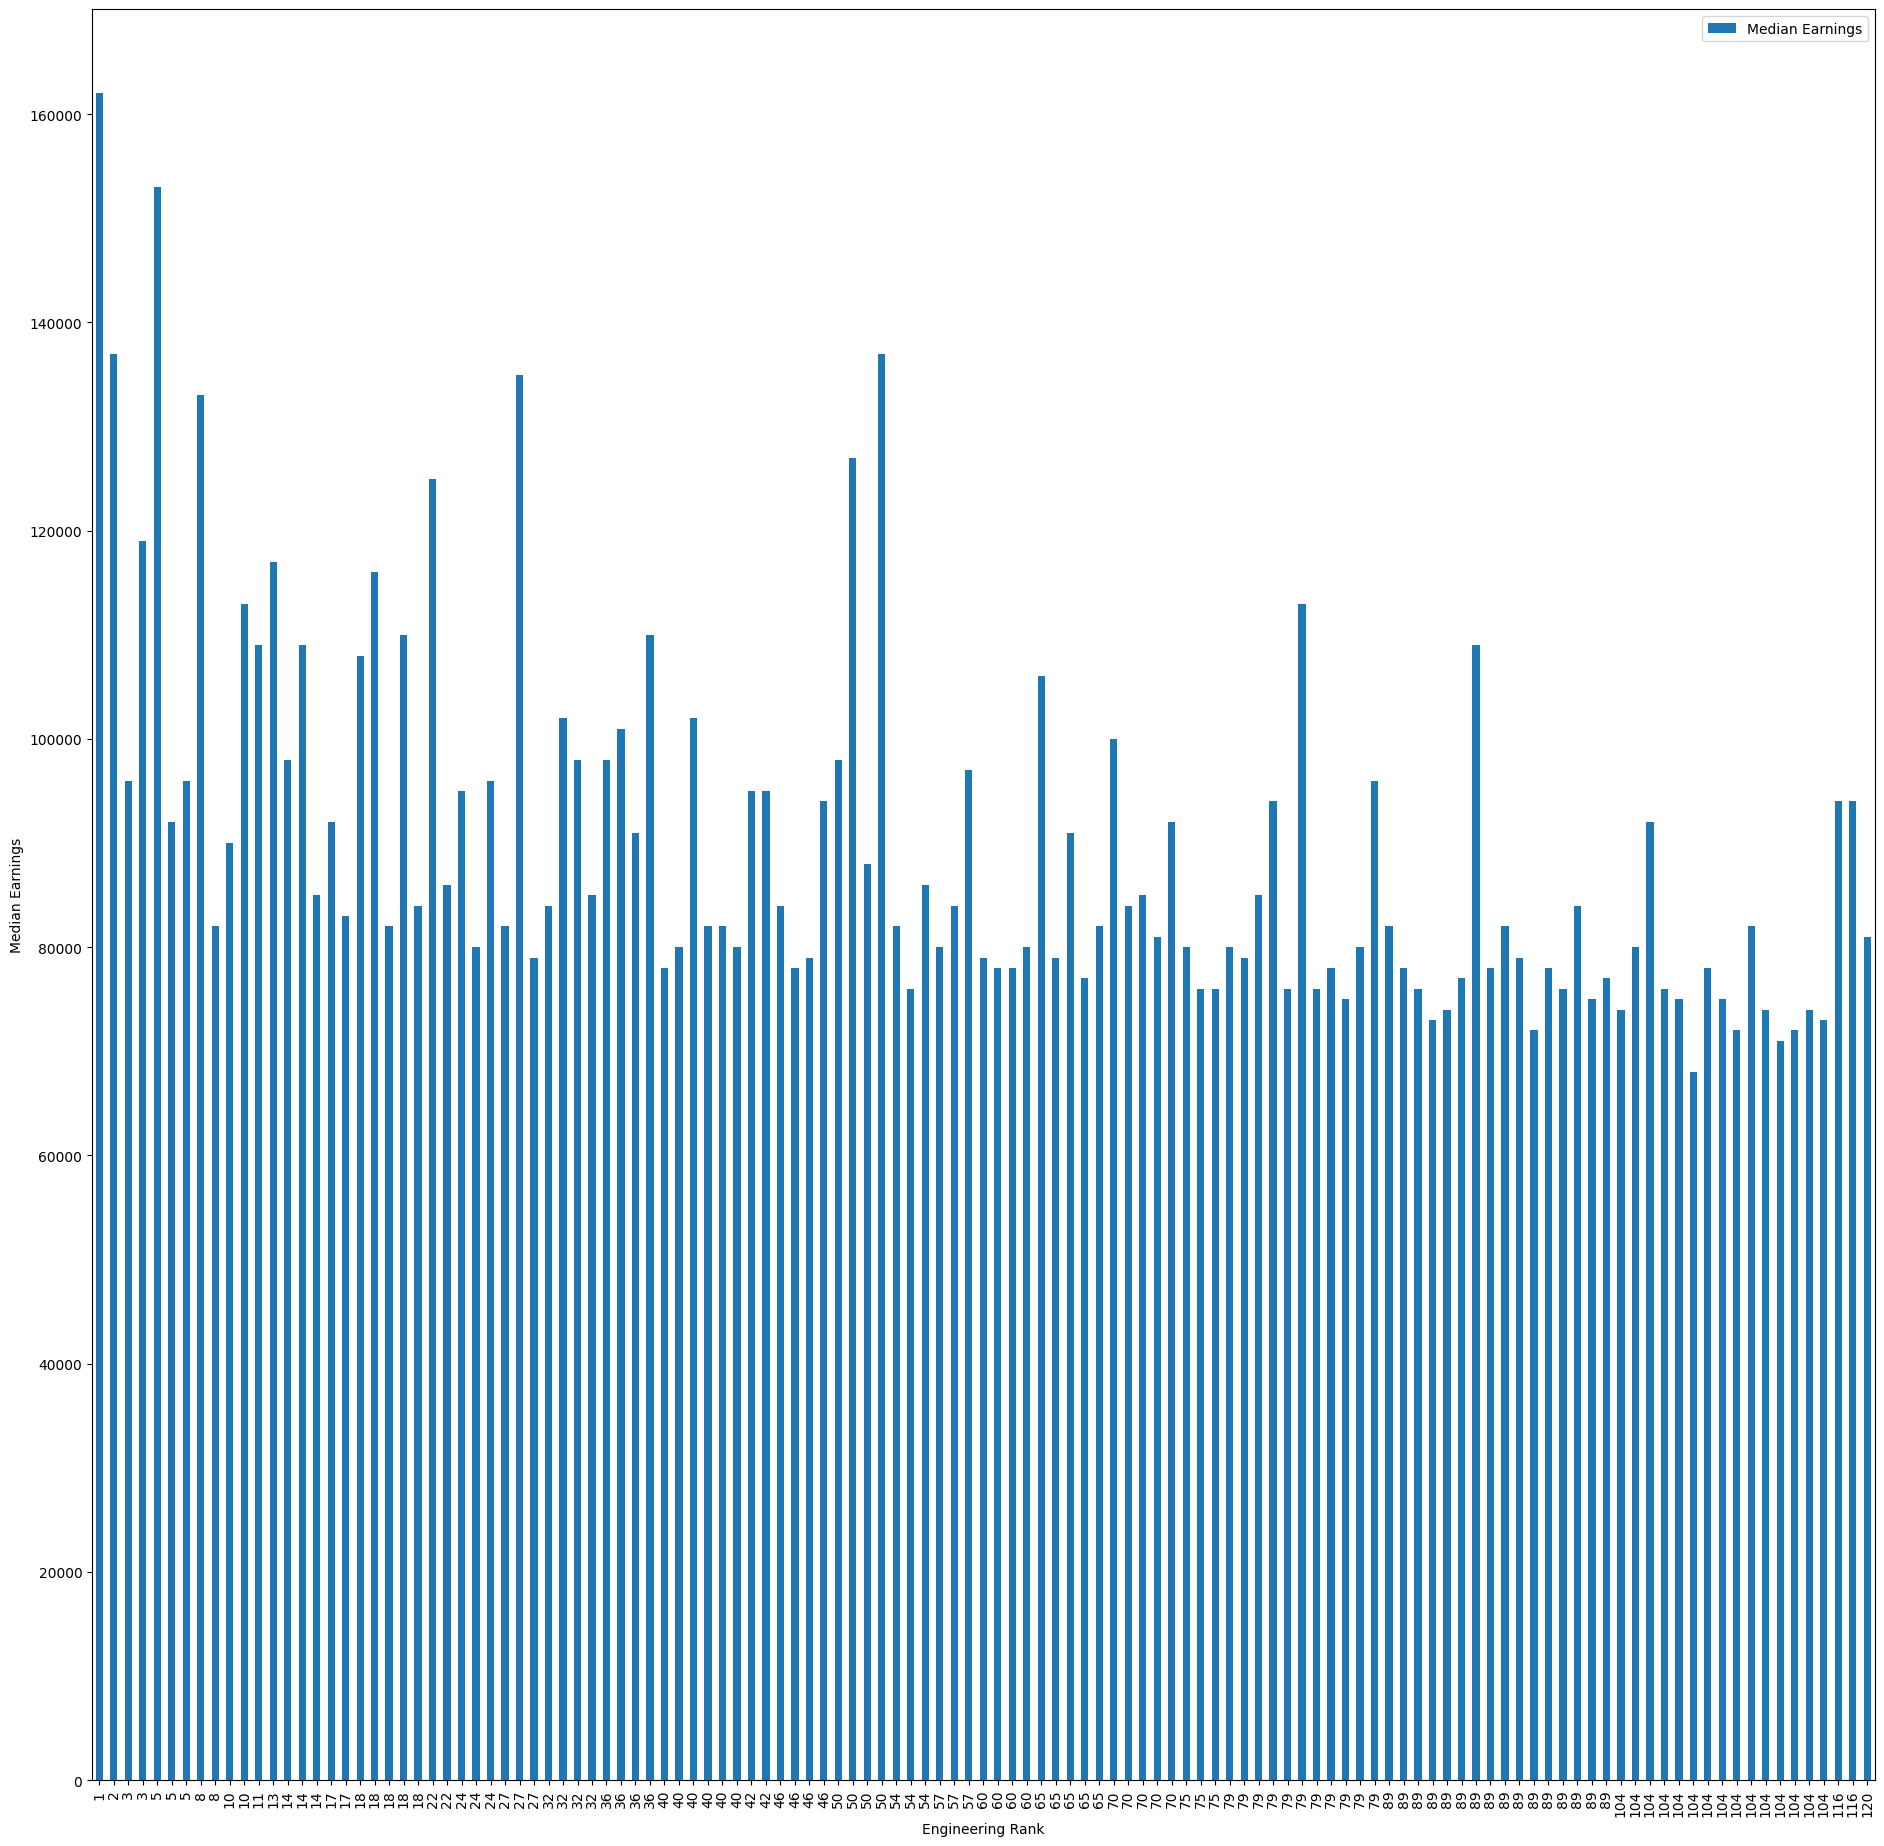

In [7]:
##Plot 2
ai_college_list.plot.bar(y = "Median Earnings", x = "Engineering Rank",ylabel = "Median Earnings", figsize =(23,23))
ai_college_list["Engineering Rank"].corr(ai_college_list["Median Earnings"])


Plot #3 compares the Average ACT scores for incoming freshmen to their earnings after they graduate using another bar graph. There again exists a clear positvely proportional trend as the graph progresses that becomes more quadratic once the 33 mark is reached. There also exists some significant outliers that stick way above the schools around them, which may indicate something.


np.float64(0.755139218480303)

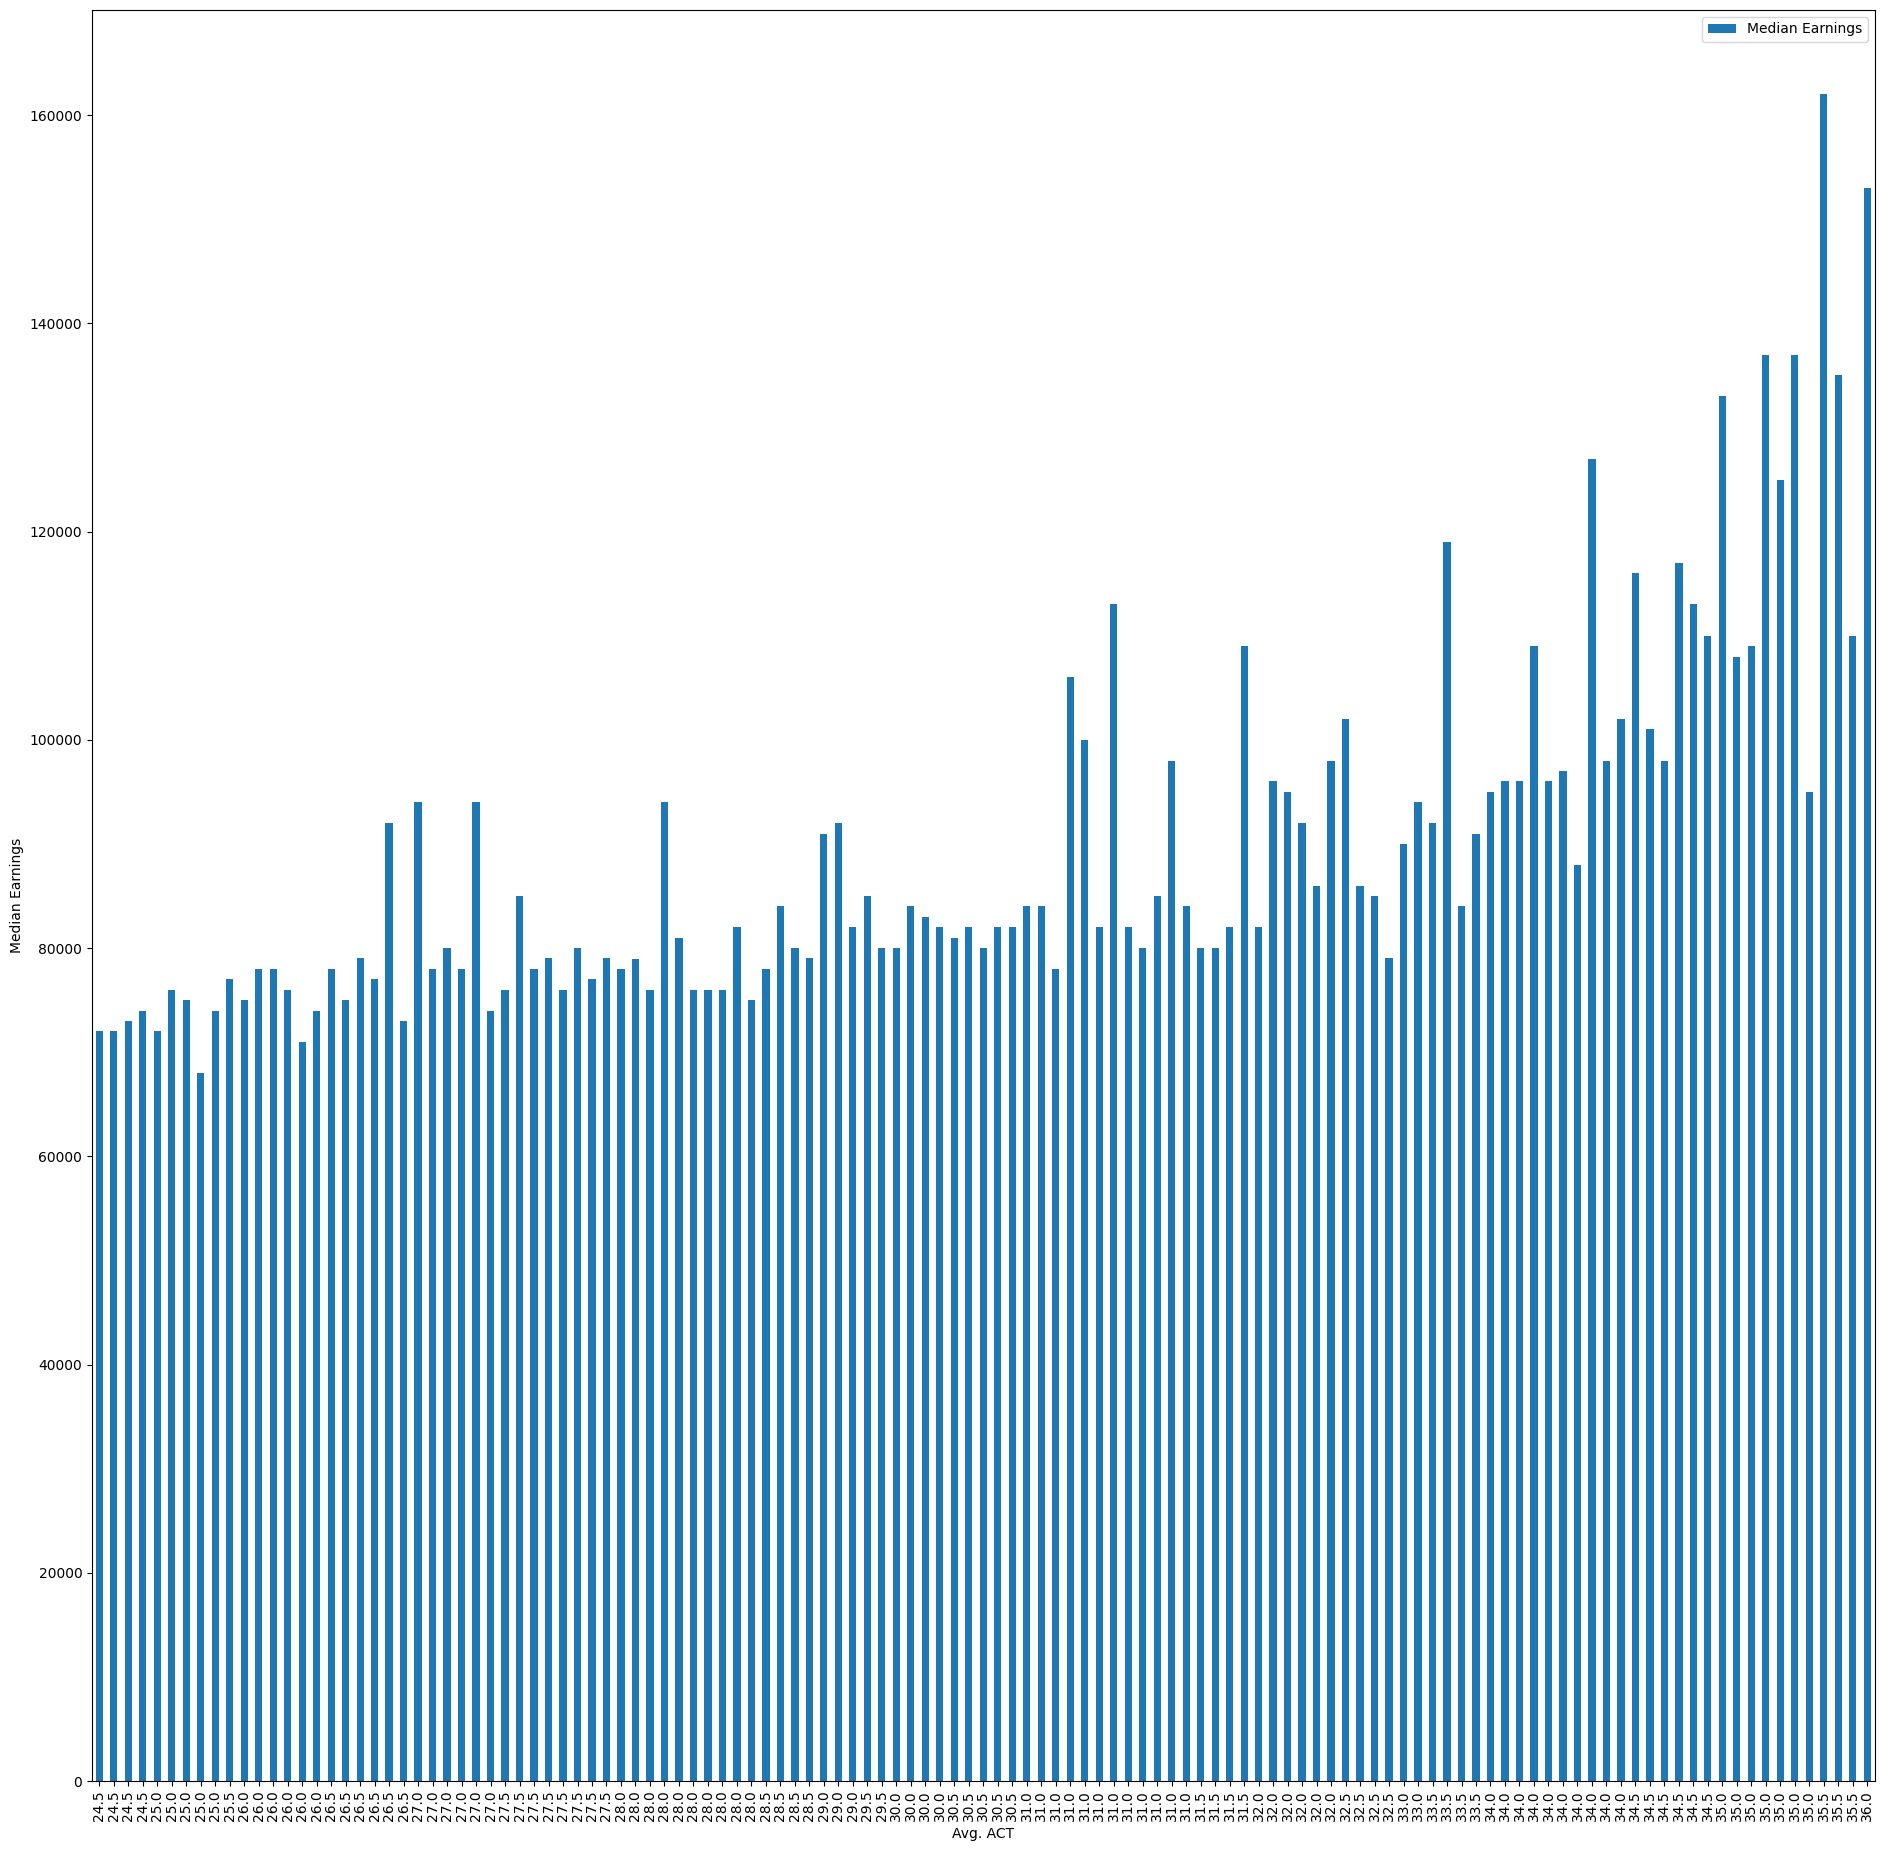

In [8]:
## Plot 3

ai_college_list_act = ai_college_list.sort_values(by = 'Avg. ACT')
ai_college_list_act.plot.bar(x= "Avg. ACT", y = "Median Earnings", figsize = (23,23), ylabel = "Median Earnings" )
ai_college_list['Avg. ACT'].corr(ai_college_list["Median Earnings"])


Plot #4 compares graduation rates to postcollege earnings. Intrestingly, there is essentially no trend in the data until the graduation rate hits 90 after which median earnings shoots up. This may be due to the fact that students seldom transfer or drop out of colleges with extremely positive outcomes and bring the graduation rate nearly to the maximum.

np.float64(0.6837225501602101)

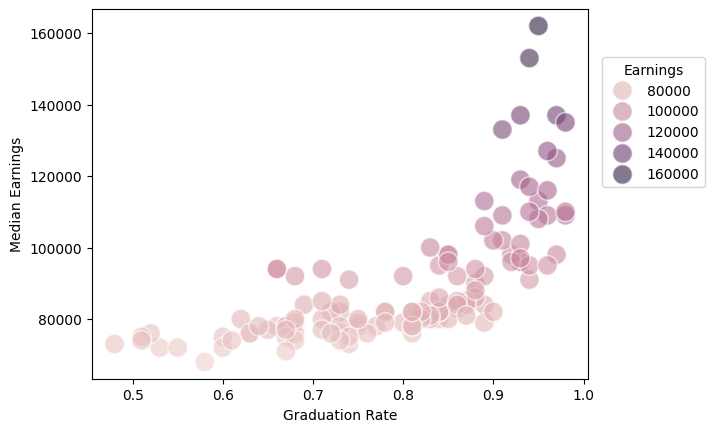

In [9]:
# Plot 4
plt1 = sns.scatterplot(ai_college_list, x="Graduation Rate", y= 'Median Earnings' , s = 200, alpha = .6, hue = "Median Earnings")
plt1.legend(title = "Earnings", loc = "lower right",
  bbox_to_anchor = (1.25,0.5))
ai_college_list["Graduation Rate"].corr(ai_college_list["Median Earnings"])


#III: The Analysis


---

To answer our 4 questions, we need to dig deeper into the data. We wil use two primary methods to group and categorize colleges by our preferred paremeters. Up first is data clustering



In [10]:
### Cluster 1 is the outcomes for students in relation to the cost, essentially worthwhileness
### Cluster 2 Is how hard it is to get into the school and how smart the average incoming HS student is
### Cluster 3 simply groups colleges by cost
import seaborn as sns
from os import statvfs
from sklearn.cluster import KMeans
modelaicollege = KMeans(6, random_state = 5)
outcomesaicollege = ["Graduation Rate","Median Earnings"]
modelaicollege.fit(ai_college_list[outcomesaicollege])
modelaicollege.cluster_centers_
ai_college_list["Outcome Clusters"] = modelaicollege.predict(ai_college_list[outcomesaicollege])
statsaicollege = ["AR","Avg. GPA", "Avg. ACT"]
modelaicollege.fit(ai_college_list[statsaicollege])
modelaicollege.cluster_centers_
ai_college_list["Stats Clusters"] = modelaicollege.predict(ai_college_list[statsaicollege])
priceaicollege = ["Average Annual Cost"]
modelaicollege.fit(ai_college_list[priceaicollege])
modelaicollege.cluster_centers_
ai_college_list["Cost Clusters"] = modelaicollege.predict(ai_college_list[priceaicollege])


In [11]:
#  All nomenclature is within the context of the stats analysis, which is exclusively higher-ranked schools
#0 = good outcomes , 1 = average outcomes , 2 = great outcomes , 3 = very good outcomes , 4 = decent outcomes  5 = elite outcomes

ai_college_outcomes_good= ai_college_list[ai_college_list['Outcome Clusters']== 0]
ai_college_outcomes_average = ai_college_list[ai_college_list['Outcome Clusters'] == 1]
ai_college_outcomes_great = ai_college_list[ai_college_list['Outcome Clusters'] == 2]
ai_college_outcomes_very_good = ai_college_list[ai_college_list['Outcome Clusters'] == 3]
ai_college_outcomes_decent= ai_college_list[ai_college_list['Outcome Clusters'] == 4]
ai_college_outcomes_elite = ai_college_list[ai_college_list['Outcome Clusters'] == 5]
ai_college_outcomes_good_range = ai_college_list[(ai_college_list['Outcome Clusters'] == 3) |(ai_college_list['Outcome Clusters'] == 2) | (ai_college_list['Outcome Clusters'] == 5) ]
ai_college_outcomes_average_range = ai_college_list[(ai_college_list['Outcome Clusters'] == 4) |(ai_college_list['Outcome Clusters'] == 1) | (ai_college_list['Outcome Clusters'] == 0) ]

ai_college_outcomes_good_range

,Name,Engineering Rank,AR,Avg. GPA,Avg. ACT,Average Annual Cost,Graduation Rate,Median Earnings,Outcome Clusters,Stats Clusters,Cost Clusters
0,MIT,1,4.0,4.00,35.5,20232,0.95,162000,5,0,1
1,Stanford,2,4.0,3.99,35.0,14443,0.97,137000,2,0,4
3,Georgia Tech,3,12.0,3.91,33.5,38000,0.93,119000,3,0,5
4,Caltech,5,3.0,3.99,36.0,16000,0.94,153000,5,0,1
7,CMU,8,11.0,3.91,35.0,33643,0.91,133000,2,0,5
10,Cornell,10,7.0,3.92,34.5,29000,0.95,113000,3,0,2
11,Princeton,11,6.0,3.95,35.0,11115,0.98,109000,3,0,4
12,Johns Hopkins,13,6.5,3.93,34.5,25207,0.94,117000,3,0,2
14,Northwestern,14,7.0,3.98,34.0,29000,0.96,109000,3,0,2
18,Columbia,18,4.5,3.95,35.0,22874,0.95,108000,3,0,1


In [12]:
#  All nomenclature is within the context of the stats analysis, which is exclusively higher-ranked schools
#0 = high cost, 1 = lower cost, 2 = midlevel cost , 3 = highest cost , 4 = lowest cost  5 = higher cost

ai_college_cost_high = ai_college_list[ai_college_list["Cost Clusters"] == 0]
ai_college_cost_lower = ai_college_list[ai_college_list["Cost Clusters"] == 1]
ai_college_cost_mid = ai_college_list[ai_college_list["Cost Clusters"] == 2]
ai_college_cost_highest= ai_college_list[ai_college_list["Cost Clusters"] == 3]
ai_college_cost_lowest = ai_college_list[ai_college_list["Cost Clusters"]== 4]
ai_college_cost_higher = ai_college_list[ai_college_list["Cost Clusters"] == 5]
ai_college_cost_high_cluster = ai_college_list[(ai_college_list["Cost Clusters"] == 5) | (ai_college_list["Cost Clusters"] == 3) | (ai_college_list["Cost Clusters"] == 0)]
ai_college_cost_low_cluster = ai_college_list[(ai_college_list["Cost Clusters"] == 1) | (ai_college_list["Cost Clusters"] == 2) | (ai_college_list["Cost Clusters"] == 4)]

In [13]:

#  All nomenclature is within the context of the stats analysis, which is exclusively higher-ranked schools
#0 = elite stats, 1 = lower stats, 2 = decent stats , 3 = pretty good stats, 4 = high stats 5 = very high stats

ai_college_stats_elite =ai_college_list[ai_college_list["Stats Clusters"]  == 0]
ai_college_stats_lower =ai_college_list[ai_college_list["Stats Clusters"] == 1]
ai_college_stats_decent =ai_college_list[ai_college_list["Stats Clusters"] == 2]
ai_college_stats_pretty_high =ai_college_list[ai_college_list["Stats Clusters"]  == 3]
ai_college_stats_high =ai_college_list[ai_college_list["Stats Clusters"] == 4]
ai_college_stats_very_high =ai_college_list[ai_college_list["Stats Clusters"]  == 5]
ai_college_stats_high_clusters =ai_college_list[(ai_college_list["Stats Clusters"]  == 5) |(ai_college_list["Stats Clusters"] == 4) | (ai_college_list["Stats Clusters"]  == 0)]
aI_college_stats_low_clusters = ai_college_list[(ai_college_list["Stats Clusters"]  == 1) |(ai_college_list["Stats Clusters"] == 2) | (ai_college_list["Stats Clusters"]  == 3)]


Up Next will be two linear regression models.

## Rank Prediction
---

The first shown below attempts to give an Expected Rank for the schools based on their outcomes. It references the graduation rate and the earnings coming out of the schools back to their rank to generate the expectancy. I also created a discrepancy column for which positive values mean a college is underrated compared to the model and negative meaning its overrated.

In [14]:
from sklearn.linear_model import LinearRegression


ind2 = ["Engineering Rank"]
dep2 = ["Median Earnings", "Graduation Rate"]

model2 = LinearRegression()
model2 = model2.fit(ai_college_list[dep2],ai_college_list[ind2])
model2

ai_college_list["Rank Prediction"] = model2.predict(ai_college_list[dep2])
ai_college_list["Rank Discrepancy"] = ai_college_list["Engineering Rank"] - ai_college_list["Rank Prediction"]


## Outcome Prediction

---



This model takes the stats of incoming freshmen as well as the rank of each school and references them with the median earnings of recent graduates to generate an expectancy calculation. For this discrepancy, the more negative it is the lower the actual earnings is from the expected.

In [15]:
 from sklearn.linear_model import LinearRegression
 ind2 = ["Median Earnings"]
 dep2 =["Graduation Rate","Avg. GPA", 'Avg. ACT', 'AR']

 modelai1 = LinearRegression()
 modelai1 = modelai1.fit(ai_college_list[dep2],ai_college_list[ind2])
 modelai1

 ai_college_list["Outcome Prediction"] = modelai1.predict(ai_college_list[dep2])
 ai_college_list["Outcome Discrepancy"] = ai_college_list["Median Earnings"] - ai_college_list["Outcome Prediction"]




In [52]:
ai_college_cost_high_cluster = ai_college_list[(ai_college_list["Cost Clusters"] == 5) | (ai_college_list["Cost Clusters"] == 3) | (ai_college_list["Cost Clusters"] == 0)]
ai_college_cost_low_cluster = ai_college_list[(ai_college_list["Cost Clusters"] == 1) | (ai_college_list["Cost Clusters"] == 2) | (ai_college_list["Cost Clusters"] == 4)]
ai_college_stats_high_clusters =ai_college_list[(ai_college_list["Stats Clusters"]  == 5) |(ai_college_list["Stats Clusters"] == 4) | (ai_college_list["Stats Clusters"]  == 0)]
ai_college_stats_low_clusters = ai_college_list[(ai_college_list["Stats Clusters"]  == 1) |(ai_college_list["Stats Clusters"] == 2) | (ai_college_list["Stats Clusters"]  == 3)]
ai_college_outcomes_good_range = ai_college_list[(ai_college_list['Outcome Clusters'] == 3) |(ai_college_list['Outcome Clusters'] == 2) | (ai_college_list['Outcome Clusters'] == 5) ]
ai_college_outcomes_average_range = ai_college_list[(ai_college_list['Outcome Clusters'] == 4) |(ai_college_list['Outcome Clusters'] == 1) | (ai_college_list['Outcome Clusters'] == 0) ]



# IV: Data Science


---




Now that we have clustered and modeled our data, we can more closely analyze trends. To accomplish this, we will compare these many data points via charts.

###Let's see how cost impacts outcomes first.

 First is a correlation between median income and average cost using our clustering to filter only for schools with median outgoing incomes roughly above $90,000. The lack of any correlation lends evidence to an answer for question 4; That is, higher actual costs do not translate to making more money going out inherently.

np.float64(-0.15273291661127916)

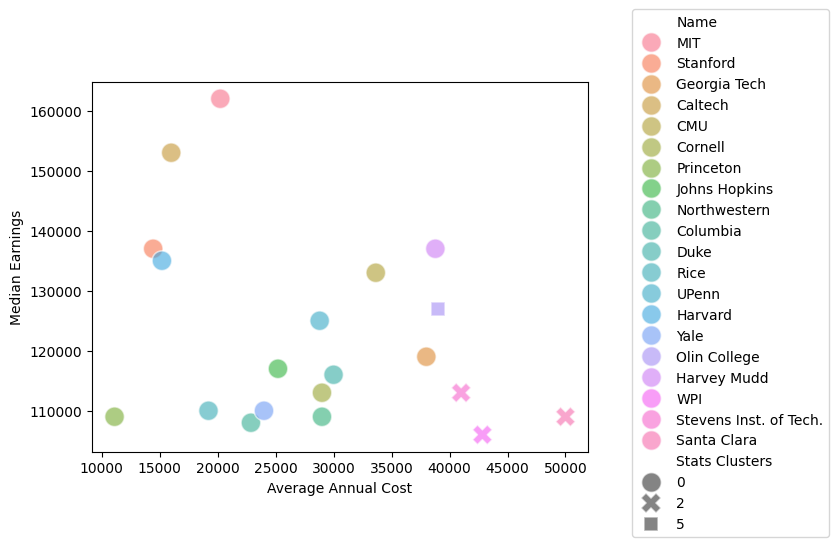

In [17]:
# Plot 5
#  All nomenclature is within the context of the stats analysis, which is exclusively higher-ranked schools
#0 = good outcomes , 1 = average outcomes , 2 = great outcomes , 3 = very good outcomes , 4 = decent outcomes  5 = elite outcomes
#0 = elite stats, 1 = lower stats, 2 = decent stats , 3 = pretty good stats, 4 = high stats 5 = very high stats
plt5 = sns.scatterplot(ai_college_outcomes_good_range, x="Average Annual Cost", y= 'Median Earnings' , s = 200, alpha = .6, hue = "Name", style = "Stats Clusters")
plt5.legend( loc = "lower right",
  bbox_to_anchor = (1.5,-0.25))
ai_college_list["Median Earnings"].corr(ai_college_list["Average Annual Cost"])


## Stats

---



The next two graphs take only high earning/graduation schools and compares their average ACT and GPA for incoming freshmen with their median earnings. This is possibly the most interesting graph, as there are some pretty significant outliers on it.

The three biggest ones are WPI, Stevens Institute of Technology and Santa Clara University. These schools are all in very close proximity to major engineering markets (Boston, NYC, San Francisco respectively). What this may lend credence to is the idea that location plays a massive role in placement along with pure course rigor and school prestige.

The third graph compares the expected earnings of each school, which is derived from all incoming freshman stats and the acceptance rate, to actual earnings.

np.float64(0.5224801493378977)

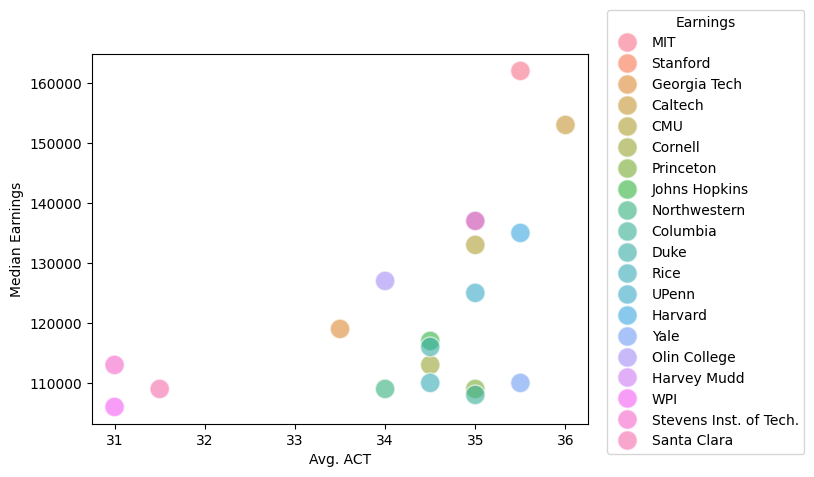

In [18]:
#  All nomenclature is within the context of the stats analysis, which is exclusively higher-ranked schools
#0 = good outcomes , 1 = average outcomes , 2 = great outcomes , 3 = very good outcomes , 4 = decent outcomes  5 = elite outcomes
#0 = elite stats, 1 = lower stats, 2 = decent stats , 3 = pretty good stats, 4 = high stats 5 = very high stats

plt6 = sns.scatterplot(ai_college_outcomes_good_range, x="Avg. ACT", y= 'Median Earnings' , s = 200, alpha = .6, hue = "Name")
plt6.legend(title = "Earnings", loc = "lower right",
  bbox_to_anchor = (1.45,-0.1))
ai_college_outcomes_good_range["Median Earnings"].corr(ai_college_outcomes_good_range["Avg. ACT"])

np.float64(0.5478675111811423)

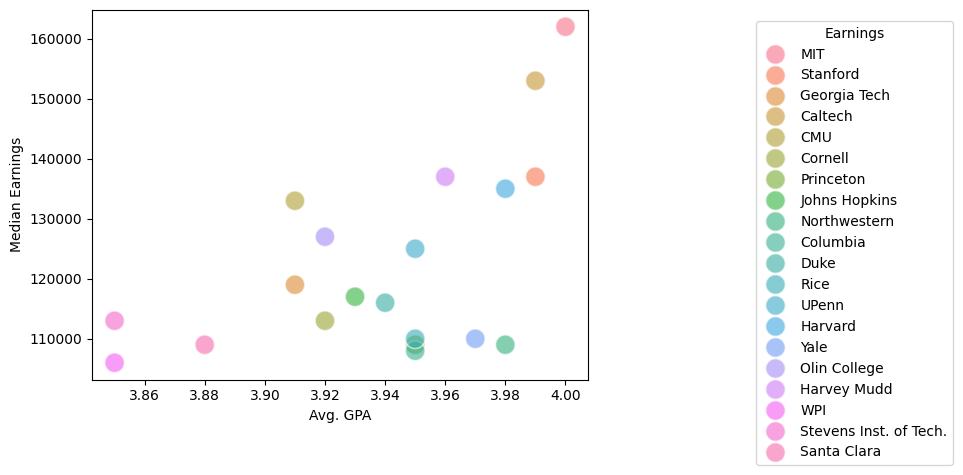

In [19]:
#  All nomenclature is within the context of the stats analysis, which is exclusively higher-ranked schools
#0 = good outcomes , 1 = average outcomes , 2 = great outcomes , 3 = very good outcomes , 4 = decent outcomes  5 = elite outcomes
#0 = elite stats, 1 = lower stats, 2 = decent stats , 3 = pretty good stats, 4 = high stats 5 = very high stats


plt7 = sns.scatterplot(ai_college_outcomes_good_range, x="Avg. GPA", y= 'Median Earnings' , s = 200, alpha = .6, hue = "Name")
plt7.legend(title = "Earnings", loc = "lower right",
  bbox_to_anchor = (1.75,-.25))
ai_college_outcomes_good_range["Median Earnings"].corr(ai_college_outcomes_good_range["Avg. GPA"])

np.float64(0.756803847363355)

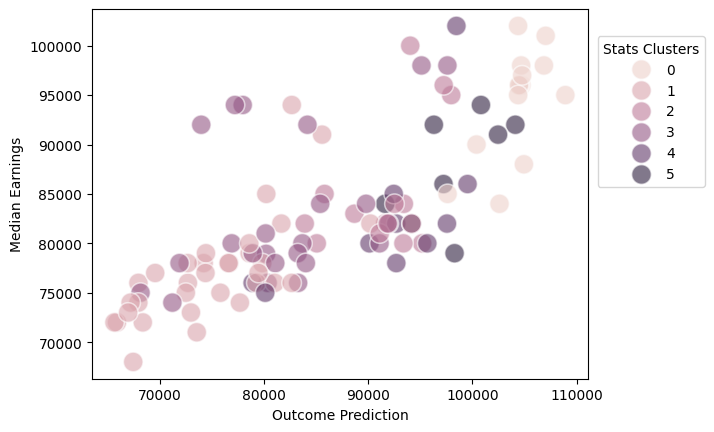

In [20]:
#  All nomenclature is within the context of the stats analysis, which is exclusively higher-ranked schools
#0 = good outcomes , 1 = average outcomes , 2 = great outcomes , 3 = very good outcomes , 4 = decent outcomes  5 = elite outcomes
#0 = elite stats, 1 = lower stats, 2 = decent stats , 3 = pretty good stats, 4 = high stats 5 = very high stats


plt8 = sns.scatterplot(ai_college_outcomes_average_range, x="Outcome Prediction", y= 'Median Earnings' , s = 200, alpha = .6, hue = "Stats Clusters")
plt8.legend(title = "Stats Clusters", loc = "lower right",
  bbox_to_anchor = (1.25,.5))
ai_college_list["Median Earnings"].corr(ai_college_list["Outcome Prediction"])

Here is the same data but without MIT and Caltech

np.float64(0.764381321646733)

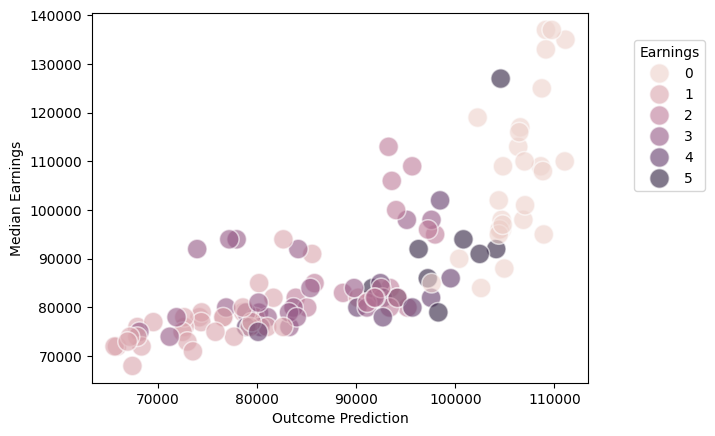

In [21]:
#  All nomenclature is within the context of the stats analysis, which is exclusively higher-ranked schools
#0 = good outcomes , 1 = average outcomes , 2 = great outcomes , 3 = very good outcomes , 4 = decent outcomes  5 = elite outcomes
#0 = elite stats, 1 = lower stats, 2 = decent stats , 3 = pretty good stats, 4 = high stats 5 = very high stats

minustheoutliers = ai_college_list[(ai_college_list.Name != "MIT") & (ai_college_list.Name != "Caltech")]
plt9 = sns.scatterplot(minustheoutliers, x="Outcome Prediction", y= 'Median Earnings' , s = 200, alpha = .6, hue = "Stats Clusters")
plt9.legend(title = "Earnings", loc = "lower right",
  bbox_to_anchor = (1.25,.5))
minustheoutliers
minustheoutliers["Median Earnings"].corr(minustheoutliers["Outcome Prediction"])

## Rankings


---





Let's now run a couple analyses concering the Engineering Rank to see how much it actually matters.

The first chart compares the actual rank of the schools to the expected rank predicted by the model with the points colored by their cost clusters. Notice first that there is a general upward trend with a decently strong correlation. There clearly exists a link between rankings and your expected success.  However, also notice how many outliers and outperformers there are. A significant number of schools have expectancies way higher than their actual rank and a decent number are the reverse case. The cost coloring is further proof that the cost of the school AFTER AID has minimal to do with the outcomes.

The second compares the rank with the actual earnings clusters. Notice the lack of any grouping here. You'd expect for each line to be clustered around a rank range if ranks directly correlated to outcomes, but instead the dots are all up and down the rankings. That school ranked around 60 in the second cluster is Harvey Mudd College, one of the best schools for networking/recruiting in the country. Its low rank somewhat has to do with its lack of a graduate program.

np.float64(0.7081875142602736)

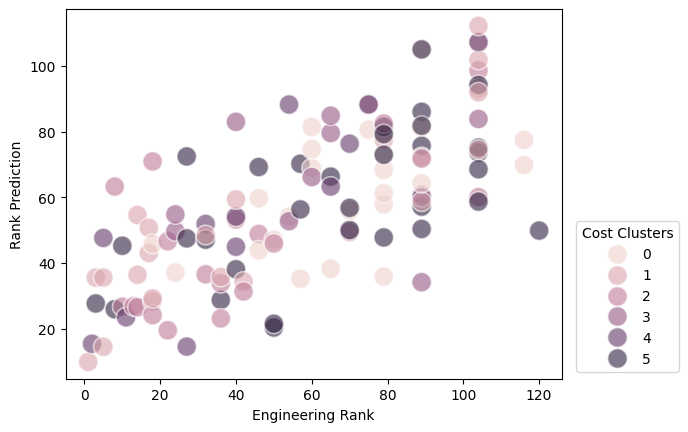

In [22]:
#  All nomenclature is within the context of the stats analysis, which is exclusively higher-ranked schools
#0 = high cost, 1 = lower cost, 2 = midlevel cost , 3 = highest cost , 4 = lowest cost  5 = higher cost
plt10 = sns.scatterplot(ai_college_list, x="Engineering Rank", y= 'Rank Prediction' , s = 200, alpha = .6, hue = "Cost Clusters")
plt10.legend(title = "Cost Clusters", loc = "lower right",
  bbox_to_anchor = (1.25,0))
ai_college_list["Engineering Rank"].corr(ai_college_list["Rank Prediction"])

np.float64(-0.5723929475493874)

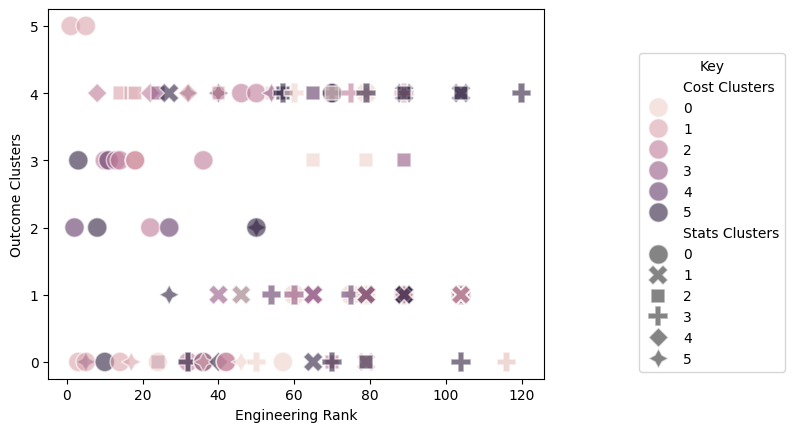

In [23]:
#  All nomenclature is within the context of the stats analysis, which is exclusively higher-ranked schools
#0 = good outcomes , 1 = average outcomes , 2 = great outcomes , 3 = very good outcomes , 4 = decent outcomes  5 = elite outcomes
#0 = high cost, 1 = lower cost, 2 = midlevel cost , 3 = highest cost , 4 = lowest cost  5 = higher cost
#0 = elite stats, 1 = lower stats, 2 = decent stats , 3 = pretty good stats, 4 = high stats 5 = very high stats

plt11 = sns.scatterplot(ai_college_list, x="Engineering Rank", y= 'Outcome Clusters' , s = 200, alpha = .6, style = "Stats Clusters",hue = "Cost Clusters")
plt11.legend(title = "Key", loc = "lower right",
  bbox_to_anchor = (1.5
              ,0))
ai_college_list["Engineering Rank"].corr(ai_college_list["Median Earnings"])

## Acceptance Rate + Academic Profile

Finally, let's check how the selectiveness of the school impacts the outcomes. We will use 3 graphs to determine our answer.

The first graphs takes the bottom three outcome clusters (which still includes some very good schools) and graphs their acceptance rate and median earnings.

The second graph does the same with the upper 3 clusters.

The third and fourth repeat the same process as the first and second but with graduation rates



The fifth uses those lower three clusters but still graphs the AR against the outcome prediction, which used the rate along with the stats to find a prediction.


The trend line is pretty clear: lower acceptance rate leads to higher earnings out of school. It also is correlated with graduation rate very closely

np.float64(-0.6408200261454738)

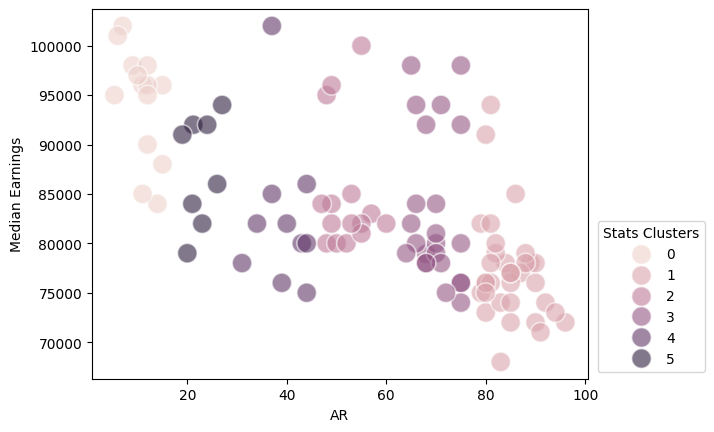

In [24]:
#  All nomenclature is within the context of the stats analysis, which is exclusively higher-ranked schools
#0 = good outcomes , 1 = average outcomes , 2 = great outcomes , 3 = very good outcomes , 4 = decent outcomes  5 = elite outcomes
#0 = high cost, 1 = lower cost, 2 = midlevel cost , 3 = highest cost , 4 = lowest cost  5 = higher cost
#0 = elite stats, 1 = lower stats, 2 = decent stats , 3 = pretty good stats, 4 = high stats 5 = very high stats

plt11 = sns.scatterplot(ai_college_outcomes_average_range, x="AR", y= 'Median Earnings' , s = 200, alpha = .6, hue = "Stats Clusters")
plt11.legend(title = "Stats Clusters", loc = "lower right",
  bbox_to_anchor = (1.25,0))
ai_college_outcomes_average_range["AR"].corr(ai_college_outcomes_average_range["Median Earnings"])

np.float64(-0.37246648509728625)

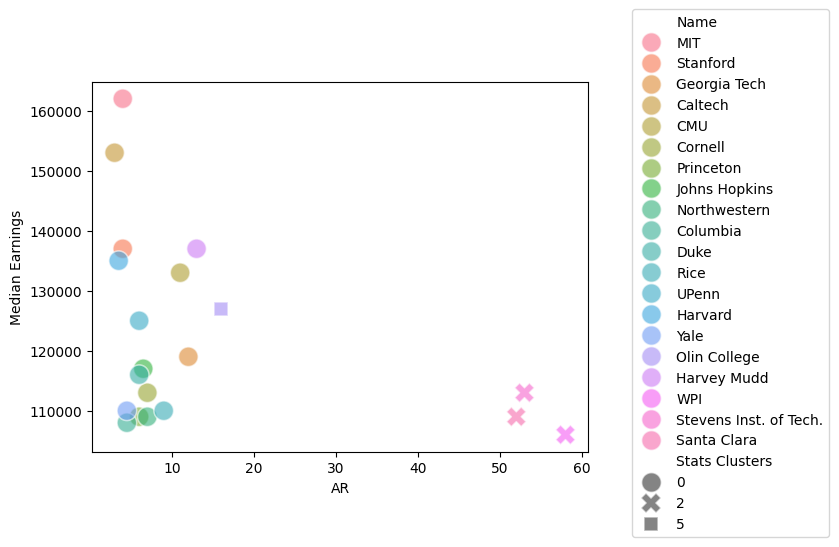

In [25]:
#  All nomenclature is within the context of the stats analysis, which is exclusively higher-ranked schools
#0 = good outcomes , 1 = average outcomes , 2 = great outcomes , 3 = very good outcomes , 4 = decent outcomes  5 = elite outcomes
#0 = high cost, 1 = lower cost, 2 = midlevel cost , 3 = highest cost , 4 = lowest cost  5 = higher cost
#0 = elite stats, 1 = lower stats, 2 = decent stats , 3 = pretty good stats, 4 = high stats 5 = very high stats

plt11 = sns.scatterplot(ai_college_outcomes_good_range, x="AR", y= 'Median Earnings' , s = 200, alpha = .6, hue = "Name" , style = "Stats Clusters")
plt11.legend( loc = "lower right",
  bbox_to_anchor = (1.5,-0.25))
ai_college_outcomes_good_range["AR"].corr(ai_college_outcomes_good_range["Median Earnings"])

np.float64(-0.8044670954009449)

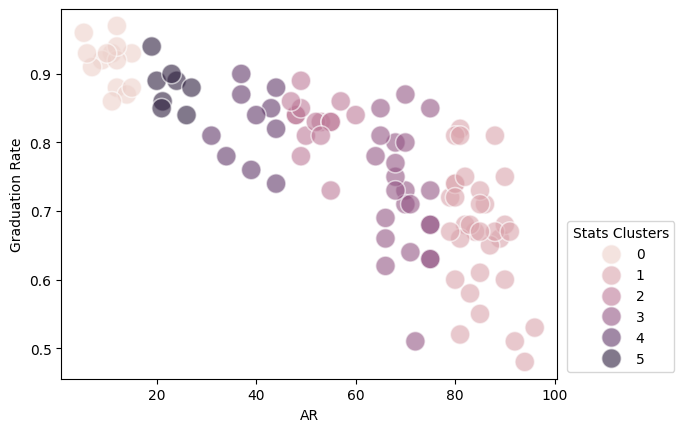

In [26]:
#  All nomenclature is within the context of the stats analysis, which is exclusively higher-ranked schools
#0 = good outcomes , 1 = average outcomes , 2 = great outcomes , 3 = very good outcomes , 4 = decent outcomes  5 = elite outcomes
#0 = high cost, 1 = lower cost, 2 = midlevel cost , 3 = highest cost , 4 = lowest cost  5 = higher cost
#0 = elite stats, 1 = lower stats, 2 = decent stats , 3 = pretty good stats, 4 = high stats 5 = very high stats

plt11 = sns.scatterplot(ai_college_outcomes_average_range, x="AR", y= 'Graduation Rate' , s = 200, alpha = .6, hue = "Stats Clusters")
plt11.legend(title = "Stats Clusters", loc = "lower right",
  bbox_to_anchor = (1.25,0))
ai_college_outcomes_average_range["AR"].corr(ai_college_outcomes_average_range["Graduation Rate"])

np.float64(-0.7927858298712404)

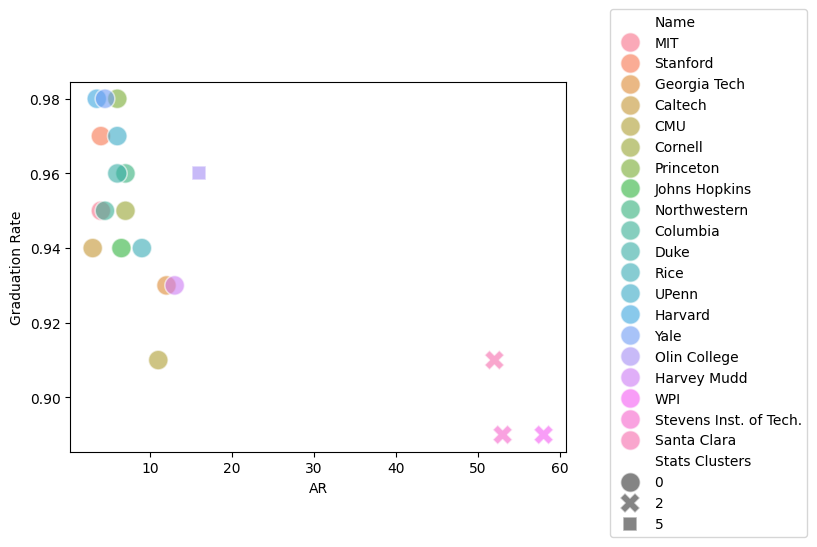

In [27]:
#  All nomenclature is within the context of the stats analysis, which is exclusively higher-ranked schools
#0 = good outcomes , 1 = average outcomes , 2 = great outcomes , 3 = very good outcomes , 4 = decent outcomes  5 = elite outcomes
#0 = high cost, 1 = lower cost, 2 = midlevel cost , 3 = highest cost , 4 = lowest cost  5 = higher cost
#0 = elite stats, 1 = lower stats, 2 = decent stats , 3 = pretty good stats, 4 = high stats 5 = very high stats

plt11 = sns.scatterplot(ai_college_outcomes_good_range, x="AR", y= 'Graduation Rate' , s = 200, alpha = .6, style = "Stats Clusters", hue = "Name")
plt11.legend( loc = "lower right",
  bbox_to_anchor = (1.5,-0.25))
ai_college_outcomes_good_range["AR"].corr(ai_college_outcomes_good_range["Graduation Rate"])

np.float64(-0.8858552256046165)

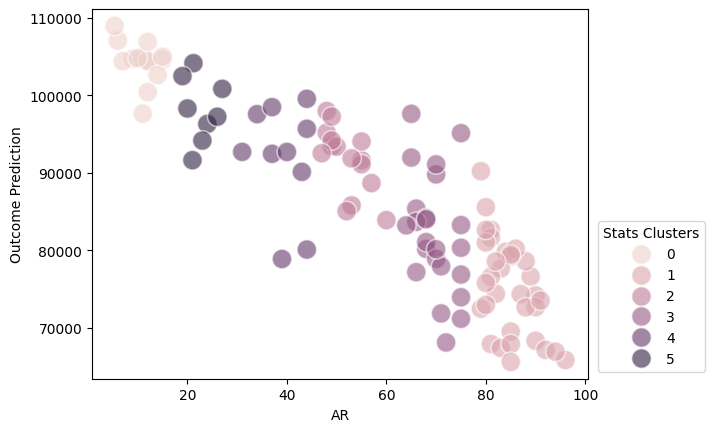

In [28]:
#  All nomenclature is within the context of the stats analysis, which is exclusively higher-ranked schools
#0 = good outcomes , 1 = average outcomes , 2 = great outcomes , 3 = very good outcomes , 4 = decent outcomes  5 = elite outcomes
#0 = high cost, 1 = lower cost, 2 = midlevel cost , 3 = highest cost , 4 = lowest cost  5 = higher cost
#0 = elite stats, 1 = lower stats, 2 = decent stats , 3 = pretty good stats, 4 = high stats 5 = very high stats

plt11 = sns.scatterplot(ai_college_outcomes_average_range, x="AR", y= 'Outcome Prediction' , s = 200, alpha = .6, hue = "Stats Clusters")
plt11.legend(title = "Stats Clusters", loc = "lower right",
  bbox_to_anchor = (1.25,0))
ai_college_outcomes_average_range["Outcome Prediction"].corr(ai_college_outcomes_average_range["AR"])

# V: Conclusions


---


Finally, we can firmly answer these questions


###Does the selctiveness of a college directly link to better outcomes?


---


Yes. Every measure and graph that tested the acceptance rate of the schools, regardless of how good the set of schools was, showed a strong correlation in the positive direction. More selective schools generally are so for a reason. More people apply to the limited spots becasue the school produces students that make more money fresh out of college and graduate at a higher rate. The high graduation rates seen with the high AR schools means that very few students transfer, which may be indiciative of students at these schools valuing their education and experience and feeling where they are is the best place, or at least a great place, to learn and prepare for the workforce.

###Does the required profile for entry directly link to better outcomes?


---


This question is similar to the last one and has a similar answer: yes*. There is a strong-ish correlation with stats to graduation rate and a stronger one to median earnings. The outcome predicition model, which takes the acadmeic profile exclusively into account, produced a very linear model with higher stat schools being expected to have better outcomes. However, incoming freshamn stats are not the end all be all. There were plenty of schools with slightly and even moderately lower stats that stood out for performing as well as high-stat schools for income and graduation rates. These schools are able to do this primarily thanks to their location but also because their incredible educations are often overshadowed by larger schools in the big markets they sit in. So while schools that take in stronger students generally outperform, it is not absolute and there is no way to verifibaly conclude one school is a better fit than another purely based on stats.


###Does higher cost directly link to better outcomes?


---


NO. Not much needs to be said with this one. Every single graph that incorporated cost showed very minimal to zero correlation. Just because a college costs more doesn't mean you'll be better off. Total cost can be high or low for a myriad of reasons, but academic outcomes is rarely one.

!Disclaimer! : The highest value private schools have ludicrious tuitions but were brought way down thanks to the significant financial aid their students receive on a broad scale.

###Does the ranking of the college lead to better outcomes?


---


Yesn't. The data for the college rankings showed a muddy picture. While for short ranges rankings were not indiciative of much (the gap in income  between the twenties and the teens was very minimal), it did matter on a large scale. The #70 is going to offer worse outcomes on average than the #30, which will be worse than #7. However, there were some outliers such as Harvey Mudd being at 50 and performing easily like a top 10.

 The final verdict: Rankings are fine for finding "good" engineering schools but shouldn't infuence decision making much beyond that.
###Is the academic prowess of the college the determining factor for job placement?


---


No. The question is very rigid in its logic. The place you come from cannot determine who you are. While the data points to schools with better acadmeic bodies are generally going to produce higher earning graduations at a higher rate of graduations. However, each data point represents thousands of individuals who have their own abilities and experiences. The determining factor in job placement is YOU, and YOU can succeed anywhere.

#Platform Demo

---

Here is practically what my platform will do for students in the club: take in score and eventually preferences such as campus/location and filter for them.

In [51]:

def Selector (ACT, GPA, cost, cost_range):

    if ACT >= 29:
      fit_schools = ai_college_list[(ai_college_list["Avg. ACT"] >= ACT - 5) & (ai_college_list["Avg. ACT"] <= ACT  +2) & (ai_college_list["Avg. GPA"] >= GPA - 1) & (ai_college_list["Avg. GPA"] <= GPA + 0.25) & (ai_college_list["Average Annual Cost"] <= cost + cost_range)]
    else:
      fit_schools = ai_college_list[(ai_college_list["Avg. ACT"] <= ACT +4) & (ai_college_list["Avg. GPA"] >= GPA  +0.25) & (ai_college_list["Average Annual Cost"] <= cost + cost_range)]
    return fit_schools.sort_values(by = "Median Earnings", ascending = False)
Selector(34.5,3.92, 25000,10000)

,Name,Engineering Rank,AR,Avg. GPA,Avg. ACT,Average Annual Cost,Graduation Rate,Median Earnings,Outcome Clusters,Stats Clusters,Cost Clusters,Rank Prediction,Rank Discrepancy,Outcome Prediction,Outcome Discrepancy
0,MIT,1,4.00,4.00,35.5,20232,0.95,162000,5,0,1,9.868544,-8.868544,111730.387834,50269.612166
4,Caltech,5,3.00,3.99,36.0,16000,0.94,153000,5,0,1,14.479939,-9.479939,113882.386241,39117.613759
1,Stanford,2,4.00,3.99,35.0,14443,0.97,137000,2,0,4,15.382513,-13.382513,109136.774225,27863.225775
29,Harvard,27,3.50,3.98,35.5,15200,0.98,135000,2,0,4,14.540987,12.459013,111110.828743,23889.171257
7,CMU,8,11.00,3.91,35.0,33643,0.91,133000,2,0,5,25.915115,-17.915115,109131.873489,23868.126511
23,UPenn,22,6.00,3.95,35.0,28802,0.97,125000,2,0,2,19.495097,2.504903,108722.101253,16277.898747
12,Johns Hopkins,13,6.50,3.93,34.5,25207,0.94,117000,3,0,2,26.817690,-13.817690,106550.405107,10449.594893
19,Duke,18,6.00,3.94,34.5,30000,0.96,116000,3,0,2,24.106492,-6.106492,106443.839068,9556.160932
10,Cornell,10,7.00,3.92,34.5,29000,0.95,113000,3,0,2,26.661595,-16.661595,106341.619723,6658.380277
21,Rice,18,9.00,3.95,34.5,19215,0.94,110000,3,0,1,29.216697,-11.216697,106983.774348,3016.225652




---


#Bibliography


---






https://collegescorecard.ed.gov/search?cip2=14

used same process for every school

https://www.wpi.edu/admissions/tuition-aid/cost-attendance